# Step 5: KMeans Clustering

Discover natural patterns in GTD data without assuming ideology in advance.
We label clusters AFTER fitting — the data reveals its own structure.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
from features.feature_engineer import GTDFeatureEngineer
from models.clustering import GTDClustering

df = pd.read_csv('../data/processed/gtd_processed.csv', low_memory=False)
print(f'Loaded: {len(df):,} rows')

Loaded: 181,691 rows


In [2]:
# Step 1: Build feature matrix
fe = GTDFeatureEngineer(output_dir='../data/processed')
X, df_enc = fe.fit_transform(df)
print(f'Feature matrix: {X.shape}\nFeatures: {fe.feature_names}')

INFO: Encoded region → region_enc (12 categories)
INFO: Encoded attack_type → attack_enc (9 categories)
INFO: Encoded target_type → target_enc (22 categories)
INFO: Encoded weapon_type → weapon_enc (12 categories)
INFO: Encoded ideology → ideology_enc (5 categories)
INFO: Feature matrix: 10 features: ['year_norm', 'log_killed', 'log_wounded', 'log_total_cas', 'suicide', 'success', 'region_enc', 'attack_enc', 'target_enc', 'weapon_enc']
INFO: Feature matrix shape: (181691, 10)
INFO: Saved feature artifacts → ../data/processed\feature_artifacts.pkl


Feature matrix: (181691, 10)
Features: ['year_norm', 'log_killed', 'log_wounded', 'log_total_cas', 'suicide', 'success', 'region_enc', 'attack_enc', 'target_enc', 'weapon_enc']


In [3]:
# Step 2 (optional): find best k
# clusterer_temp = GTDClustering()
# best_k = clusterer_temp.find_optimal_k(X, k_range=range(2, 10))
best_k = 6  # use 6 to align with ideology categories

In [4]:
# Step 3: Fit clusters
clusterer = GTDClustering(n_clusters=best_k)
df_enc = clusterer.fit(df_enc, X)
profiles = clusterer.profile_clusters(df_enc)

INFO: Fitting KMeans with k=6...
INFO: Cluster sizes:
cluster
0    15513
1    17338
2    60022
3     6631
4    47871
5    34316



=== CLUSTER PROFILES ===
 cluster  n_incidents dominant_ideology            dominant_region   dominant_attack  avg_killed  pct_suicide year_range
       0        15513           Unknown                 South Asia           Unknown        2.37          0.0  1970-2017
       1        17338           Unknown Middle East & North Africa Bombing/Explosion        0.22          0.0  1970-2017
       2        60022           Unknown                 South Asia Bombing/Explosion        0.60          0.0  1992-2017
       3         6631           Unknown Middle East & North Africa Bombing/Explosion       10.14        100.0  1981-2017
       4        47871           Unknown              South America Bombing/Explosion        0.50          0.0  1970-2006
       5        34316           Unknown Middle East & North Africa Bombing/Explosion        7.12          0.0  1970-2017


INFO: Running PCA for visualization...


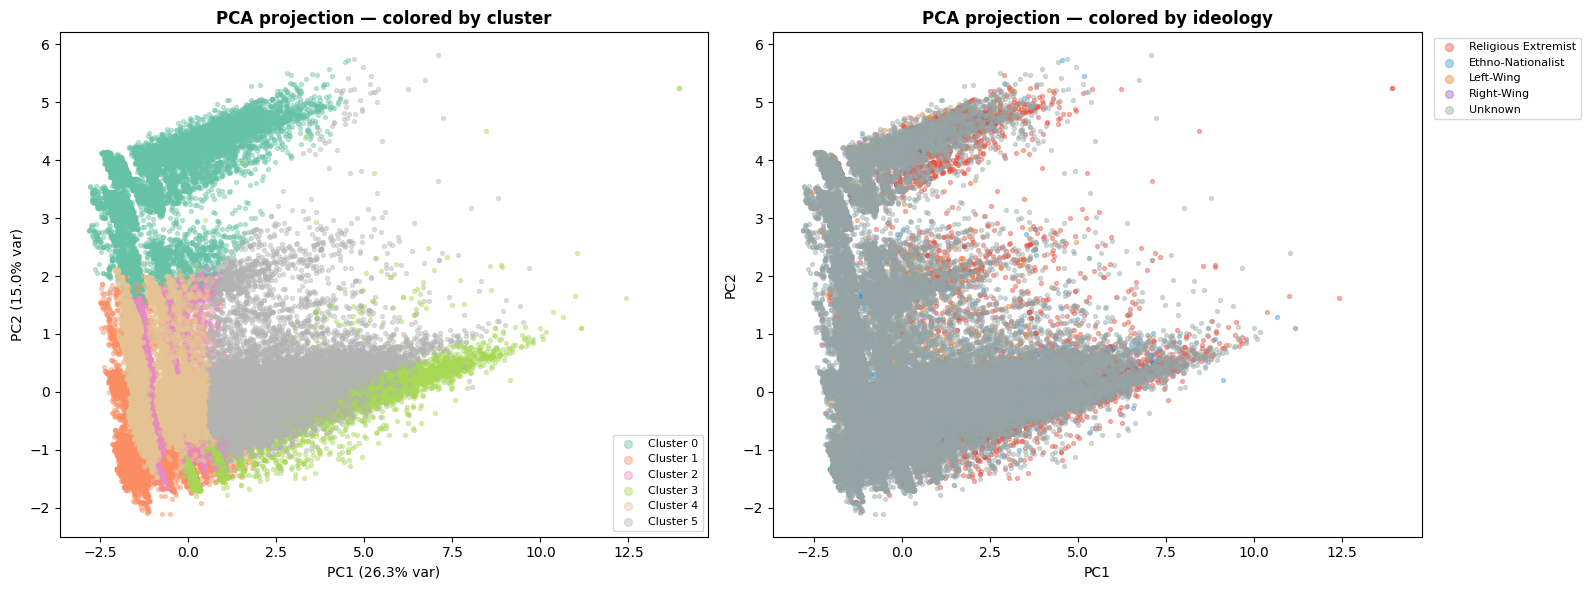

In [5]:
# Step 4: Visualize PCA projection
clusterer.visualize(df_enc, X)

In [6]:
# Step 5: Ideology purity per cluster
# Shows how well clusters align with documented ideology labels
purity = df_enc.groupby('cluster')['ideology'].value_counts(normalize=True).unstack(fill_value=0) * 100
print('Ideology % per cluster:')
print(purity.round(1).to_string())

Ideology % per cluster:
ideology  Ethno-Nationalist  Left-Wing  Religious Extremist  Right-Wing  Unknown
cluster                                                                         
0                       1.4        6.3                 24.5         0.0     67.8
1                       2.6        3.8                  7.3         0.0     86.2
2                       0.8        3.3                 15.2         0.0     80.7
3                       1.7        0.0                 47.4         0.0     50.9
4                       5.4       10.2                  0.6         0.0     83.7
5                       2.4        4.9                 17.5         0.0     75.2


In [7]:
# Save
clusterer.save('../data/processed')
df_enc.to_csv('../data/processed/gtd_clustered.csv', index=False)
profiles.to_csv('../data/processed/cluster_profiles.csv', index=False)
print('Done. Next -> notebooks/06_nlp_news.ipynb')

INFO: Model saved → ../data/processed\kmeans_model.pkl


Done. Next -> notebooks/06_nlp_news.ipynb
